# Exploratory Data Analysis Sales
Nama: Tatia Rohmatul Alsyifa 
NIM: 031202400007

## Brainstorming Questions

Pada tahap awal eksplorasi, dilakukan proses brainstorming untuk
mengidentifikasi berbagai kemungkinan pertanyaan analitis yang dapat
digali dari dataset penjualan coffee shop.

Daftar pertanyaan berikut masih bersifat eksploratif dan digunakan
sebagai dasar untuk menentukan fokus analisis lebih lanjut:

- Produk apa yang paling laris berdasarkan quantity?
- Produk apa yang menghasilkan revenue tertinggi?
- Store mana dengan total penjualan terbesar?
- Store mana dengan jumlah transaksi terbanyak?
- Bagaimana tren penjualan dari waktu ke waktu?
- Bulan mana dengan penjualan tertinggi?
- Hari apa dengan transaksi paling ramai?
- Apakah terdapat hubungan antara quantity dan sales?
- Berapa rata-rata penjualan per transaksi?
- Apakah terdapat outlier pada kolom sales?
- Apakah terdapat outlier pada kolom quantity?
- Produk mana yang performanya paling stabil?

Dari hasil brainstorming ini kemudian ditetapkan beberapa pertanyaan
utama yang akan dianalisis lebih mendalam pada tahap berikutnya.

## Research Questions

Berdasarkan hasil eksplorasi awal terhadap dataset, ditetapkan tujuh
pertanyaan analisis utama untuk menggali insight dari data penjualan
coffee shop.

Fokus analisis pada tahap ini adalah sebagai berikut:
1. Produk apa yang memiliki total revenue tertinggi?
2. Store mana yang menghasilkan total sales terbesar?
3. Bagaimana tren penjualan harian dari waktu ke waktu?
4. Hari apa yang memiliki jumlah transaksi terbanyak?
5. Apakah terdapat korelasi antara quantity dan sales?
6. Produk apa yang paling sering dibeli berdasarkan quantity?
7. Apakah terdapat outlier pada kolom sales dan quantity menggunakan metode IQR?

Pertanyaan-pertanyaan tersebut akan dijawab melalui proses data wrangling,
exploratory data analysis (EDA), serta analisis statistik yang relevan.

## Import Library

Library berikut digunakan untuk proses manipulasi data dan visualisasi.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

Dataset dibaca menggunakan pandas untuk meninjau struktur awal data.

In [2]:
df = pd.read_csv("sales.csv")
df.head()

,order_id,date,store,product,quantity,sales
0,1,01/01/2023,Lower Manhattan,Gourmet brewed coffee,2,6.0
1,2,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2
2,3,01/01/2023,Lower Manhattan,Hot chocolate,2,9.0
3,4,01/01/2023,Lower Manhattan,Drip coffee,1,2.0
4,5,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2


## Data Wrangling

Tahap ini mencakup pemeriksaan tipe data, missing values, serta duplikasi untuk memastikan kualitas data sebelum analisis.

In [7]:
# melihat struktur awal dataset
df.info()

# konversi kolom date ke format datetime (format data: DD/MM/YYYY)
df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True,
    errors='coerce'  # mencegah error jika ada format tidak valid
)

# pemeriksaan missing values
missing_values = df.isnull().sum()
missing_values

# pemeriksaan duplikasi
duplicate_count = df.duplicated().sum()
duplicate_count

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   order_id  149116 non-null  int64         
 1   date      149116 non-null  datetime64[us]
 2   store     149116 non-null  str           
 3   product   149116 non-null  str           
 4   quantity  149116 non-null  int64         
 5   sales     149116 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 6.8 MB


np.int64(0)

## Data Transformation

Untuk mendukung analisis tren waktu, dibuat dataframe agregasi harian berdasarkan total sales per tanggal.

In [8]:
df_clean = df.copy()

df_daily_sales = (
    df_clean.groupby('date')['sales']
    .sum()
    .reset_index()
)

df_daily_sales.head()

,date,sales
0,2023-01-01,2508.20
1,2023-01-02,2403.35
2,2023-01-03,2565.00
3,2023-01-04,2220.10
4,2023-01-05,2418.85


## Exploratory Data Analysis (EDA)

Statistik deskriptif digunakan untuk memahami karakteristik umum dari data numerik.
Statistik deskriptif memberikan gambaran awal mengenai distribusi data.

In [9]:
df_clean.describe()

,order_id,date,quantity,sales
count,149116.000000,149116,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609,1.438276,4.686367
min,1.000000,2023-01-01 00:00:00,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000
50%,74727.500000,2023-04-24 00:00:00,1.000000,3.750000
75%,112094.250000,2023-05-30 00:00:00,2.000000,6.000000
max,149456.000000,2023-06-30 00:00:00,8.000000,360.000000
std,43153.600016,NaN,0.542509,4.227099


### Distribusi Sales

Histogram berikut digunakan untuk mengamati pola distribusi nilai sales.Visualisasi menunjukkan bagaimana nilai sales tersebar dalam dataset.

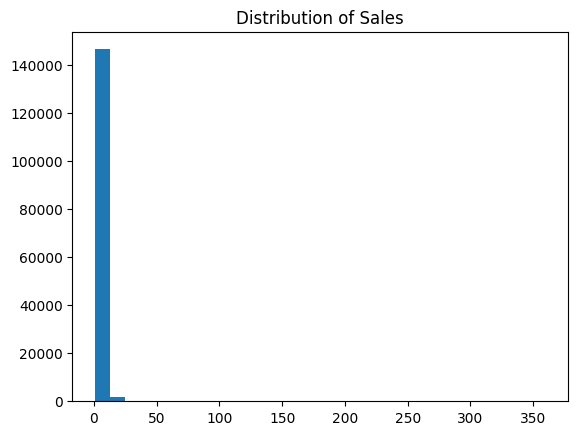

In [10]:
plt.figure()
plt.hist(df_clean['sales'], bins=30)
plt.title("Distribution of Sales")
plt.show()

## Outlier Detection menggunakan IQR

Metode Interquartile Range (IQR) digunakan karena lebih robust untuk data bisnis yang tidak selalu berdistribusi normal.

In [11]:
Q1 = df_clean['sales'].quantile(0.25)
Q3 = df_clean['sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_sales = df_clean[
    (df_clean['sales'] < lower) |
    (df_clean['sales'] > upper)
]

len(outliers_sales)

3273

Nilai di atas menunjukkan jumlah observasi yang teridentifikasi sebagai outlier pada kolom sales.

## Q1. Produk dengan total revenue tertinggi

Analisis berikut menghitung total sales untuk setiap produk.

In [12]:
df_clean.groupby('product')['sales'] \
    .sum() \
    .sort_values(ascending=False) \
    .head()

product
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Name: sales, dtype: float64

Berdasarkan total nilai penjualan per produk, terlihat bahwa
**Barista Espresso** merupakan produk dengan kontribusi sales tertinggi
yaitu sebesar **91,406.20**.

Temuan ini menunjukkan bahwa produk berbasis kopi, khususnya espresso,
memberikan kontribusi pendapatan terbesar bagi coffee shop.

### Q2. Store mana yang menghasilkan total sales terbesar?

Analisis ini bertujuan untuk mengidentifikasi store dengan kontribusi penjualan tertinggi. 
Data akan dikelompokkan berdasarkan store dan dijumlahkan total sales-nya.

In [13]:
store_sales = (
    df_clean.groupby('store')['sales']
    .sum()
    .sort_values(ascending=False)
)

store_sales

store
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: sales, dtype: float64

Dapat disimpulkan bahwa **Hell's Kitchen** merupakan store dengan performa penjualan tertinggi pada dataset ini.

### Q3. Bagaimana tren penjualan harian dari waktu ke waktu?

Analisis ini bertujuan untuk melihat pola perkembangan penjualan harian.
Data akan diagregasi per tanggal dan divisualisasikan menggunakan line chart
untuk mengamati fluktuasi penjualan dari waktu ke waktu.

In [14]:
# agregasi total sales per hari
daily_sales = (
    df.groupby('date')['sales']
      .sum()
      .sort_index()
)

# tampilkan 5 data teratas
daily_sales.head()

date
2023-01-01    2508.20
2023-01-02    2403.35
2023-01-03    2565.00
2023-01-04    2220.10
2023-01-05    2418.85
Name: sales, dtype: float64

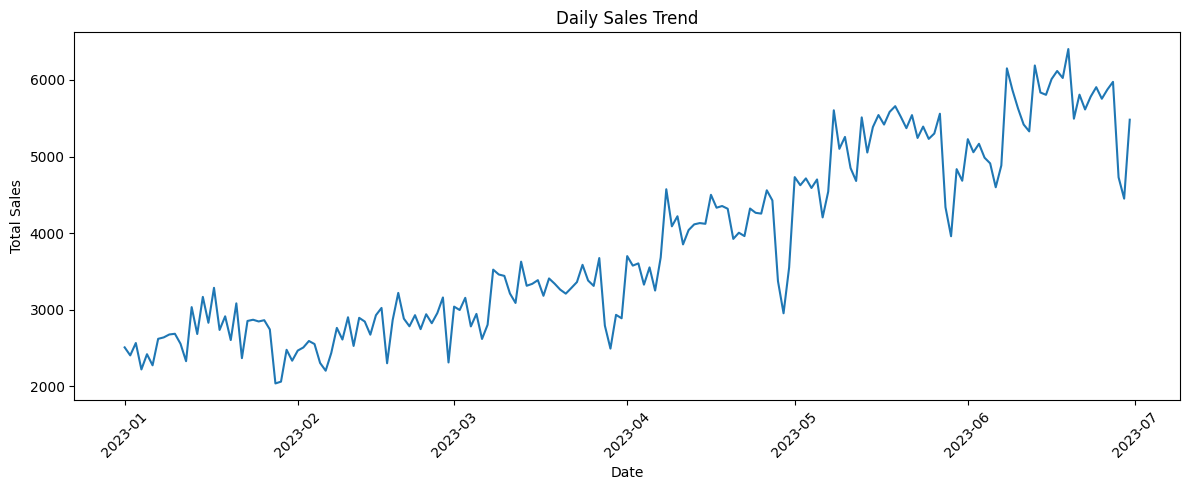

In [23]:
# plot tren penjualan harian
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretasi:**

Berdasarkan visualisasi tren penjualan harian, terlihat bahwa total sales
mengalami fluktuasi dari waktu ke waktu. Namun, secara umum terdapat
kecenderungan peningkatan penjualan seiring berjalannya periode.

Beberapa titik menunjukkan penurunan yang cukup tajam, yang dapat
mengindikasikan variasi permintaan harian atau faktor operasional tertentu.
Sementara itu, puncak penjualan yang semakin tinggi di periode akhir
menunjukkan performa penjualan yang membaik.

Secara keseluruhan, tren penjualan harian menunjukkan pola pertumbuhan
yang positif meskipun disertai fluktuasi.

### Q4. Hari apa yang memiliki jumlah transaksi terbanyak?

Analisis ini bertujuan untuk mengidentifikasi hari dengan aktivitas transaksi paling tinggi.
Kolom tanggal akan diekstrak menjadi nama hari, kemudian dihitung jumlah transaksi per hari.

In [16]:
# membuat kolom nama hari
df['day_name'] = df['date'].dt.day_name()

# cek hasil
df[['date', 'day_name']].head()

,date,day_name
0,2023-01-01,Sunday
1,2023-01-01,Sunday
2,2023-01-01,Sunday
3,2023-01-01,Sunday
4,2023-01-01,Sunday


In [17]:
# menghitung jumlah transaksi per hari
transactions_per_day = (
    df['day_name']
      .value_counts()
)

transactions_per_day

day_name
Friday       21701
Thursday     21654
Monday       21643
Wednesday    21310
Tuesday      21202
Sunday       21096
Saturday     20510
Name: count, dtype: int64

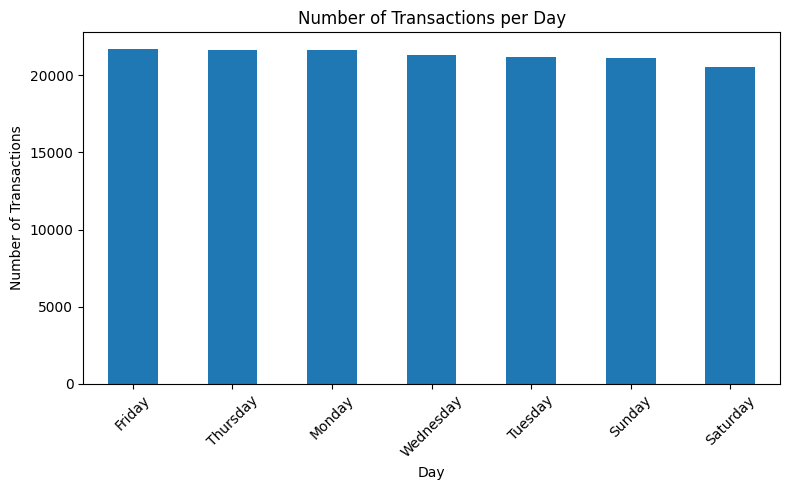

In [22]:
plt.figure(figsize=(8, 5))
transactions_per_day.plot(kind='bar')
plt.title('Number of Transactions per Day')
plt.xlabel('Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Berdasarkan hasil perhitungan jumlah transaksi per hari, terlihat bahwa
aktivitas transaksi relatif merata sepanjang minggu.

Namun, **Friday** memiliki jumlah transaksi tertinggi yaitu sebesar **21,701 transaksi**,
diikuti oleh Thursday dan Monday dengan selisih yang tidak terlalu besar.

Sementara itu, **Saturday** merupakan hari dengan jumlah transaksi terendah
yaitu sebesar **20,510 transaksi**.

Temuan ini menunjukkan bahwa tidak terdapat perbedaan ekstrem antar hari,
namun terdapat kecenderungan aktivitas transaksi sedikit lebih tinggi
menjelang akhir pekan kerja.

### Q5. Apakah terdapat korelasi antara quantity dan sales?

Analisis korelasi dilakukan untuk mengetahui hubungan antara jumlah produk
yang dibeli (quantity) dengan total penjualan (sales).

Metode yang digunakan adalah korelasi Pearson dan visualisasi scatter plot
untuk melihat pola hubungan kedua variabel.

In [19]:
# menghitung korelasi Pearson
correlation = df['quantity'].corr(df['sales'])

correlation

np.float64(0.3562308526230813)

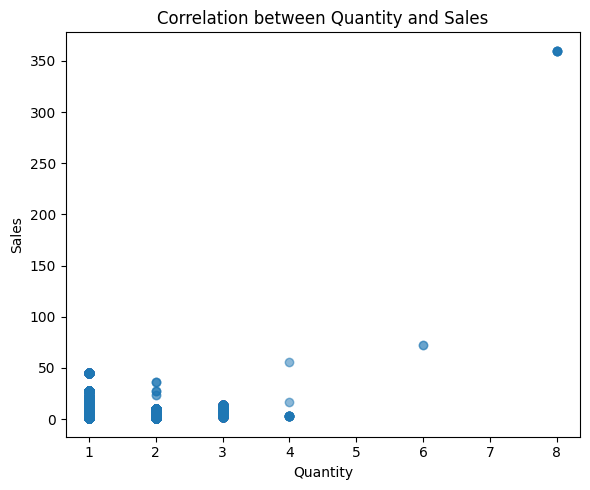

In [21]:
plt.figure(figsize=(6, 5))
plt.scatter(df['quantity'], df['sales'], alpha=0.3)
plt.title('Correlation between Quantity and Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

Nilai korelasi Pearson antara quantity dan sales adalah sebesar **0.356**.
Nilai ini menunjukkan adanya **korelasi positif lemah hingga sedang**
antara jumlah produk yang dibeli dan total penjualan.

Hal ini berarti bahwa ketika quantity meningkat, sales cenderung ikut meningkat,
namun hubungan tersebut tidak terlalu kuat. Hal ini wajar karena nilai sales
tidak hanya dipengaruhi oleh quantity, tetapi juga oleh harga masing-masing produk.

Berdasarkan scatter plot, terlihat pola hubungan yang cenderung naik,
meskipun titik data masih cukup menyebar.

### Q6. Produk apa yang paling sering dibeli berdasarkan quantity?

Analisis ini bertujuan untuk mengidentifikasi produk dengan total quantity
pembelian tertinggi. Data akan dikelompokkan berdasarkan product dan
dijumlahkan quantity-nya untuk melihat tingkat popularitas produk.

In [24]:
# total quantity per produk
top_products = (
    df.groupby('product')['quantity']
      .sum()
      .sort_values(ascending=False)
)

# tampilkan 10 teratas
top_products.head(10)

product
Brewed Chai tea          26250
Gourmet brewed coffee    25973
Barista Espresso         24943
Brewed Black tea         17462
Hot chocolate            17457
Brewed herbal tea        17328
Organic brewed coffee    13012
Drip coffee              12891
Premium brewed coffee    12431
Scone                    10465
Name: quantity, dtype: int64

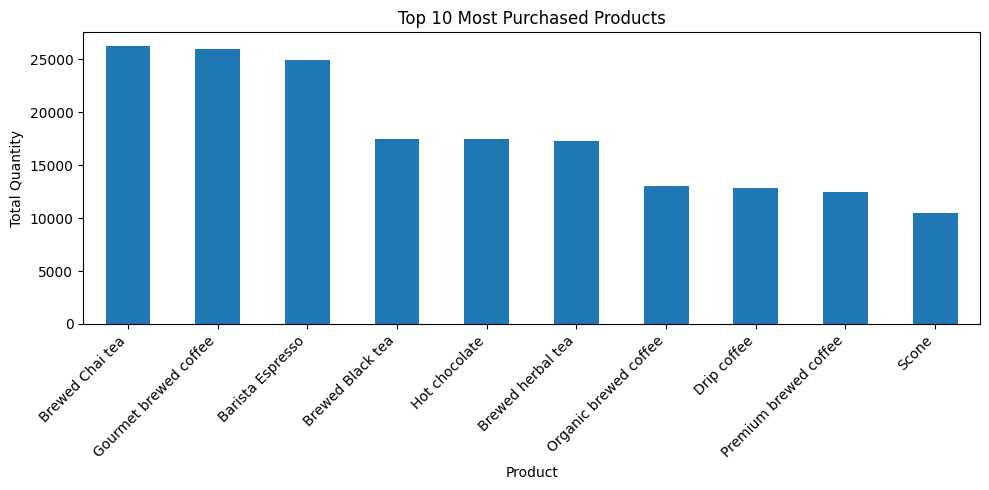

In [25]:
plt.figure(figsize=(10, 5))
top_products.head(10).plot(kind='bar')
plt.title('Top 10 Most Purchased Products')
plt.xlabel('Product')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Berdasarkan total quantity penjualan, produk yang paling sering dibeli adalah
**Brewed Chai tea** dengan total pembelian sebesar **26,250 unit**.

Posisi berikutnya ditempati oleh:
- Gourmet brewed coffee (25,973)
- Barista Espresso (24,943)

Sementara itu, **Scone** merupakan produk dengan jumlah pembelian terendah
dalam daftar top 10 yaitu sebesar **10,465 unit**.

Temuan ini menunjukkan bahwa kategori minuman, khususnya berbasis teh dan kopi,
mendominasi preferensi pembelian pelanggan.

### Q7. Apakah terdapat outlier pada kolom sales dan quantity menggunakan metode IQR?

Metode Interquartile Range (IQR) digunakan untuk mendeteksi nilai outlier
pada kolom **sales** dan **quantity**.

In [28]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    return outliers, lower_bound, upper_bound

In [29]:
sales_outliers, sales_lower, sales_upper = detect_outliers_iqr(df['sales'])

print("Sales Lower Bound:", sales_lower)
print("Sales Upper Bound:", sales_upper)
print("Number of Sales Outliers:", len(sales_outliers))

Sales Lower Bound: -1.5
Sales Upper Bound: 10.5
Number of Sales Outliers: 3273


In [30]:
qty_outliers, qty_lower, qty_upper = detect_outliers_iqr(df['quantity'])

print("Quantity Lower Bound:", qty_lower)
print("Quantity Upper Bound:", qty_upper)
print("Number of Quantity Outliers:", len(qty_outliers))

Quantity Lower Bound: -0.5
Quantity Upper Bound: 3.5
Number of Quantity Outliers: 36


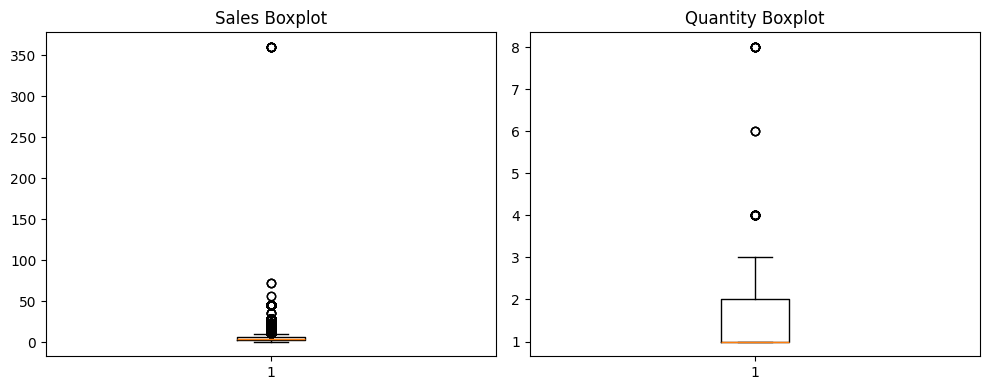

In [31]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df['sales'])
plt.title('Sales Boxplot')

plt.subplot(1,2,2)
plt.boxplot(df['quantity'])
plt.title('Quantity Boxplot')

plt.tight_layout()
plt.show()

Berdasarkan metode Interquartile Range (IQR), terdeteksi adanya outlier
pada kedua variabel yang dianalisis.

Pada kolom **sales**, ditemukan sebanyak **3,273 outlier** dengan batas atas
sebesar **10.5**. Hal ini menunjukkan terdapat sejumlah transaksi dengan
nilai penjualan yang jauh lebih tinggi dibanding mayoritas data.

Sementara itu, pada kolom **quantity**, ditemukan **36 outlier** dengan batas
atas **3.5**. Jumlah outlier pada quantity relatif kecil, yang menandakan
sebagian besar pelanggan membeli dalam jumlah yang konsisten.

Visualisasi boxplot juga memperkuat temuan ini, di mana terlihat beberapa
titik ekstrem terutama pada variabel sales.

## Kesimpulan

Berdasarkan proses Exploratory Data Analysis (EDA) yang telah dilakukan,
diperoleh beberapa insight penting dari dataset penjualan coffee shop:

1. Store dengan kontribusi penjualan tertinggi adalah Hell's Kitchen.
2. Tren penjualan harian menunjukkan kecenderungan meningkat meskipun
   terdapat fluktuasi.
3. Aktivitas transaksi relatif merata sepanjang minggu, dengan Friday
   sebagai hari tersibuk.
4. Terdapat korelasi positif lemah antara quantity dan sales.
5. Produk yang paling sering dibeli didominasi oleh kategori minuman.
6. Metode IQR menunjukkan adanya outlier terutama pada variabel sales.

Secara keseluruhan, data penjualan menunjukkan performa yang stabil
dengan beberapa variasi ekstrem yang perlu diperhatikan dalam analisis
lanjutan.